# comprisk — competing-risk regression models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunnyadn/comprisk/blob/main/examples/02_regression_models.ipynb)

Beyond the forest, `comprisk` ships the classical competing-risk regression and
non-parametric tools, each validated against the reference R packages:

| model | what it estimates | R parity |
|---|---|---|
| `FineGrayRegression` | subdistribution-hazard ratios | `cmprsk::crr()` |
| `CauseSpecificCox` | cause-specific hazard ratios | `survival::coxph()` |
| `CumulativeIncidence` | non-parametric Aalen-Johansen CIF | `cmprsk::cuminc()` |
| `gray_test` | K-sample test for equal CIFs | `cmprsk::cuminc()$Tests` |
| `PenalizedFineGrayRegression` | LASSO/MCP/SCAD Fine-Gray | `crrp::crrp()` |

> Install: `pip install comprisk` (plots need `matplotlib`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from comprisk import (
    FineGrayRegression, CauseSpecificCox, CumulativeIncidence, gray_test,
    PenalizedFineGrayRegression,
)

rng = np.random.default_rng(42)
n, p = 800, 6
X = rng.normal(size=(n, p))
lp = 0.9 * X[:, 0] + 0.5 * X[:, 1]          # only feature_0, feature_1 matter
t1 = rng.exponential(np.exp(-lp))
t2 = rng.exponential(2.0, size=n)
tc = rng.exponential(4.0, size=n)
time = np.minimum.reduce([t1, t2, tc])
event = np.where((t1 <= t2) & (t1 <= tc), 1, np.where(t2 <= tc, 2, 0))
feature_names = [f"feature_{i}" for i in range(p)]
print("event counts:", np.bincount(event))

event counts: [ 96 451 253]


## 1. Fine-Gray subdistribution hazard

`coef_` are log subdistribution-hazard ratios for the event of interest
(`cause=1`); `robust_se=True` gives the Geskus cluster-robust SE. We print the
familiar coefficient table.

In [2]:
fg = FineGrayRegression(cause=1, robust_se=True).fit(X, time=time, event=event)
z = fg.coef_ / fg.se_
fg_table = pd.DataFrame({
    "feature": feature_names,
    "coef": fg.coef_,
    "exp(coef)": np.exp(fg.coef_),
    "se(robust)": fg.se_,
    "z": z,
    "p": 2 * norm.sf(np.abs(z)),
}).round(4)
fg_table

,feature,coef,exp(coef),se(robust),z,p
0,feature_0,0.7456,2.1077,0.0544,13.7090,0.0000
1,feature_1,0.4770,1.6112,0.0510,9.3461,0.0000
2,feature_2,-0.0297,0.9707,0.0479,-0.6204,0.5350
3,feature_3,0.0061,1.0061,0.0483,0.1265,0.8993
4,feature_4,-0.0379,0.9628,0.0460,-0.8241,0.4099
5,feature_5,0.0319,1.0324,0.0505,0.6310,0.5280


## 2. Cause-specific Cox

The complementary view: a Cox model on the cause-specific hazard, with
competing events treated as censored at their event time.

In [3]:
cs = CauseSpecificCox(cause=1).fit(X, time=time, event=event)
zc = cs.coef_ / cs.se_
cs_table = pd.DataFrame({
    "feature": feature_names,
    "coef": cs.coef_,
    "HR": np.exp(cs.coef_),
    "se": cs.se_,
    "z": zc,
    "p": 2 * norm.sf(np.abs(zc)),
}).round(4)
cs_table

,feature,coef,HR,se,z,p
0,feature_0,0.8613,2.3661,0.0565,15.2389,0.0000
1,feature_1,0.5347,1.7070,0.0481,11.1287,0.0000
2,feature_2,-0.0229,0.9773,0.0463,-0.4949,0.6207
3,feature_3,-0.0125,0.9875,0.0480,-0.2614,0.7938
4,feature_4,-0.0327,0.9678,0.0437,-0.7478,0.4546
5,feature_5,-0.0020,0.9981,0.0505,-0.0387,0.9692


## 3. Non-parametric CIF by group (Aalen-Johansen)

`CumulativeIncidence` estimates the CIF without covariates; pass `group` to get
one curve per group. `curves_[(group, cause)]` is a step function with `.times`
and `.cif`. We split on the sign of feature_0 (which drives cause-1 risk).

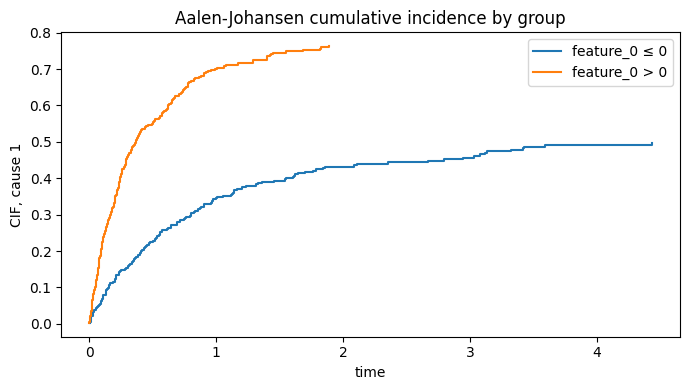

In [4]:
group = (X[:, 0] > 0).astype(int)
ci = CumulativeIncidence().fit(time=time, event=event, group=group)

fig, ax = plt.subplots(figsize=(7, 4))
for g, lbl in [(0, "feature_0 ≤ 0"), (1, "feature_0 > 0")]:
    cur = ci.curves_[(g, 1)]
    ax.step(cur.times, cur.cif, where="post", label=lbl)
ax.set_xlabel("time"); ax.set_ylabel("CIF, cause 1")
ax.set_title("Aalen-Johansen cumulative incidence by group")
ax.legend(); fig.tight_layout()
plt.show()

## 4. Gray's test

Is the cause-1 CIF the same across the two groups? Gray's K-sample test (here
the curves clearly differ, so we expect a tiny p-value).

In [5]:
res = gray_test(time, event, group, cause=1)
print(f"Gray's test  stat = {res.stat:.3f}  df = {res.df}  p = {res.pvalue:.3g}")

Gray's test  stat = 91.470  df = 1  p = 1.13e-21


## 5. Penalized Fine-Gray (LASSO path)

Cyclic coordinate descent on the IPCW-weighted partial likelihood, warm-started
along a 100-point lambda path; `cv=K` picks lambda by cross-validated deviance.
The path shows each coefficient shrinking to zero as the penalty grows — only
the two signal features survive near `lambda_min`.

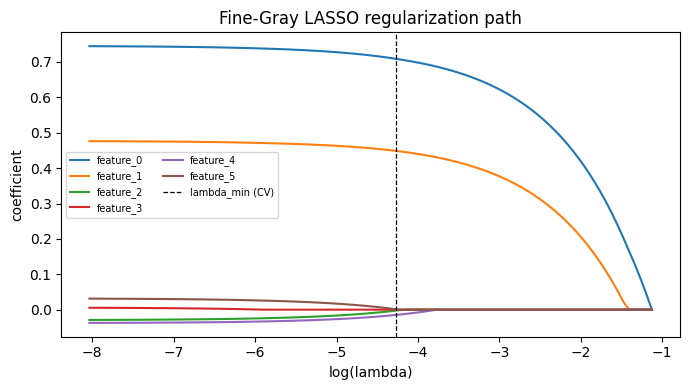

In [6]:
pen = PenalizedFineGrayRegression(penalty="lasso", cv=5,
                                  cv_random_state=0).fit(X, time=time, event=event)

fig, ax = plt.subplots(figsize=(7, 4))
ll = np.log(pen.lambdas_)
for j in range(pen.coef_path_.shape[0]):
    ax.plot(ll, pen.coef_path_[j], label=feature_names[j])
ax.axvline(np.log(pen.lambda_min_), ls="--", color="k", lw=0.9, label="lambda_min (CV)")
ax.set_xlabel("log(lambda)"); ax.set_ylabel("coefficient")
ax.set_title("Fine-Gray LASSO regularization path")
ax.legend(fontsize=7, ncol=2); fig.tight_layout()
plt.show()

## Next

- **Forest quickstart**: [`01_forest_quickstart.ipynb`](01_forest_quickstart.ipynb)
- Full reference: [`docs/quickstart.md`](../docs/quickstart.md)